In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight

In [3]:
RANDOM_STATE = 42

TARGET_COL = "alarm_active"

DATA_PATH = "../data/final_merged_dataset.parquet"
MODEL_PATH = "../models/2__hist_gradient_boosting__v1.pkl"

In [4]:
df = pd.read_parquet(DATA_PATH)
df.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,2022-02-24 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-24 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,2022-02-24 01:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,2022-02-24 01:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,2022-02-24 02:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [4]:
df.shape

(844993, 467)

In [5]:
df = df.sort_values("datetime_hour").reset_index(drop=True)

In [6]:
drop_cols = [
    TARGET_COL,
    "alarm_minutes_in_hour",
    "datetime_hour",
    "day_datetime",
    "day_sunrise",
    "day_sunset",
    "city_name",
    "region_key",
]

y = df[TARGET_COL].astype(int)

X = df.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include=["number", "bool"]).copy()

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(np.int8)

print("X shape:", X.shape)
print("Positive rate:", y.mean())
print("Bool cols:", len(bool_cols))

X shape: (844993, 459)
Positive rate: 0.2064478640651461
Bool cols: 4


In [7]:
n = len(X)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (591495, 459) (591495,)
Valid: (126749, 459) (126749,)
Test : (126749, 459) (126749,)


In [8]:
param_grid = [
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 0.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 500,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 600,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 100,
        "l2_regularization": 2.0,
    },
]

In [9]:
tscv = TimeSeriesSplit(n_splits=3)

best_params = None
best_cv_score = -np.inf
best_oof_proba = pd.Series(index=X_train.index, dtype=float)

for params in param_grid:
    fold_scores = []
    oof_proba = pd.Series(index=X_train.index, dtype=float)

    print("\nTesting params:", params)

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]

        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        sample_weight_tr = compute_sample_weight(
            class_weight="balanced",
            y=y_tr
        )

        model = HistGradientBoostingClassifier(
            loss="log_loss",
            random_state=RANDOM_STATE,
            early_stopping=False,
            **params
        )

        model.fit(X_tr, y_tr, sample_weight=sample_weight_tr)

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_proba.iloc[val_idx] = val_proba

        fold_roc = roc_auc_score(y_val, val_proba)
        fold_ap = average_precision_score(y_val, val_proba)
        fold_scores.append(fold_roc)

        print(f"  Fold {fold}: ROC-AUC = {fold_roc:.4f} | PR-AUC = {fold_ap:.4f}")

    mean_score = float(np.mean(fold_scores))
    print(f"Mean CV ROC-AUC = {mean_score:.4f}")

    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_params = params
        best_oof_proba = oof_proba.copy()

print("\nBest params:", best_params)
print("Best CV ROC-AUC:", round(best_cv_score, 4))


Testing params: {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 0.0}
  Fold 1: ROC-AUC = 0.8543 | PR-AUC = 0.5373
  Fold 2: ROC-AUC = 0.8822 | PR-AUC = 0.6581
  Fold 3: ROC-AUC = 0.9004 | PR-AUC = 0.7601
Mean CV ROC-AUC = 0.8790

Testing params: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 1.0}
  Fold 1: ROC-AUC = 0.8553 | PR-AUC = 0.5384
  Fold 2: ROC-AUC = 0.8829 | PR-AUC = 0.6627
  Fold 3: ROC-AUC = 0.9008 | PR-AUC = 0.7632
Mean CV ROC-AUC = 0.8797

Testing params: {'learning_rate': 0.03, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 1.0}
  Fold 1: ROC-AUC = 0.8567 | PR-AUC = 0.5474
  Fold 2: ROC-AUC = 0.8829 | PR-AUC = 0.6641
  Fold 3: ROC-AUC = 0.9017 | PR-AUC = 0.7667
Mean CV ROC-AUC = 0.8804

Testing params: {'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 2.0

In [10]:
threshold_grid = np.arange(0.30, 0.71, 0.05)

valid_mask = best_oof_proba.notna()
y_oof = y_train.loc[valid_mask]
proba_oof = best_oof_proba.loc[valid_mask]

best_threshold = 0.50
best_threshold_f1 = -np.inf

for thr in threshold_grid:
    pred_oof = (proba_oof >= thr).astype(int)
    score = f1_score(y_oof, pred_oof, zero_division=0)

    print(f"threshold={thr:.2f} : OOF F1={score:.4f}")

    if score > best_threshold_f1:
        best_threshold_f1 = score
        best_threshold = float(thr)

print("\nBest threshold:", best_threshold)
print("Best OOF F1:", round(best_threshold_f1, 4))

threshold=0.30 : OOF F1=0.5945
threshold=0.35 : OOF F1=0.6140
threshold=0.40 : OOF F1=0.6300
threshold=0.45 : OOF F1=0.6440
threshold=0.50 : OOF F1=0.6545
threshold=0.55 : OOF F1=0.6613
threshold=0.60 : OOF F1=0.6638
threshold=0.65 : OOF F1=0.6612
threshold=0.70 : OOF F1=0.6522

Best threshold: 0.5999999999999999
Best OOF F1: 0.6638


In [11]:
sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

final_model = HistGradientBoostingClassifier(
    loss="log_loss",
    random_state=RANDOM_STATE,
    early_stopping=False,
    **best_params
)

final_model.fit(X_train, y_train, sample_weight=sample_weight_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",600
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",63
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",100
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",2.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_

In [12]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
f1 = f1_score(y_test, test_pred, zero_division=0)
precision = precision_score(y_test, test_pred, zero_division=0)
recall = recall_score(y_test, test_pred, zero_division=0)

print("=== FINAL TEST METRICS ===")
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))
print("F1       :", round(f1, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

=== FINAL TEST METRICS ===
ROC-AUC  : 0.9408
PR-AUC   : 0.8731
F1       : 0.8036
Precision: 0.7422
Recall   : 0.8762

Classification report:
              precision    recall  f1-score   support

           0     0.9451    0.8751    0.9088     89872
           1     0.7422    0.8762    0.8036     36877

    accuracy                         0.8754    126749
   macro avg     0.8436    0.8756    0.8562    126749
weighted avg     0.8861    0.8754    0.8782    126749



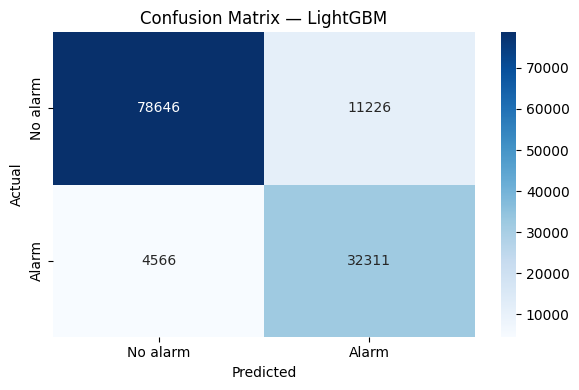

In [13]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No alarm", "Alarm"],
            yticklabels=["No alarm", "Alarm"])
plt.title("Confusion Matrix — LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [14]:
sample_size = min(20000, len(X_test))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=sample_size, replace=False)

X_perm = X_test.iloc[sample_idx].copy()
y_perm = y_test.iloc[sample_idx].copy()

perm = permutation_importance(
    estimator=final_model,
    X=X_perm,
    y=y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

top20 = importance_df.head(20).copy()
top20

,feature,importance_mean,importance_std
435,alarm_lag_1,0.316395,0.003095
439,alarms_in_last_24h,0.064194,0.002542
187,tg_topic_2,0.017282,0.000860
0,region_id,0.010545,0.001236
443,neighbour_alarms,0.009370,0.000313
34,hour,0.003514,0.000330
186,tg_topic_1,0.003242,0.000555
444,hours_since_last_alarm,0.002187,0.000555
442,total_active_alarms_lag1,0.001657,0.000102
15,hour_humidity,0.001016,0.000253


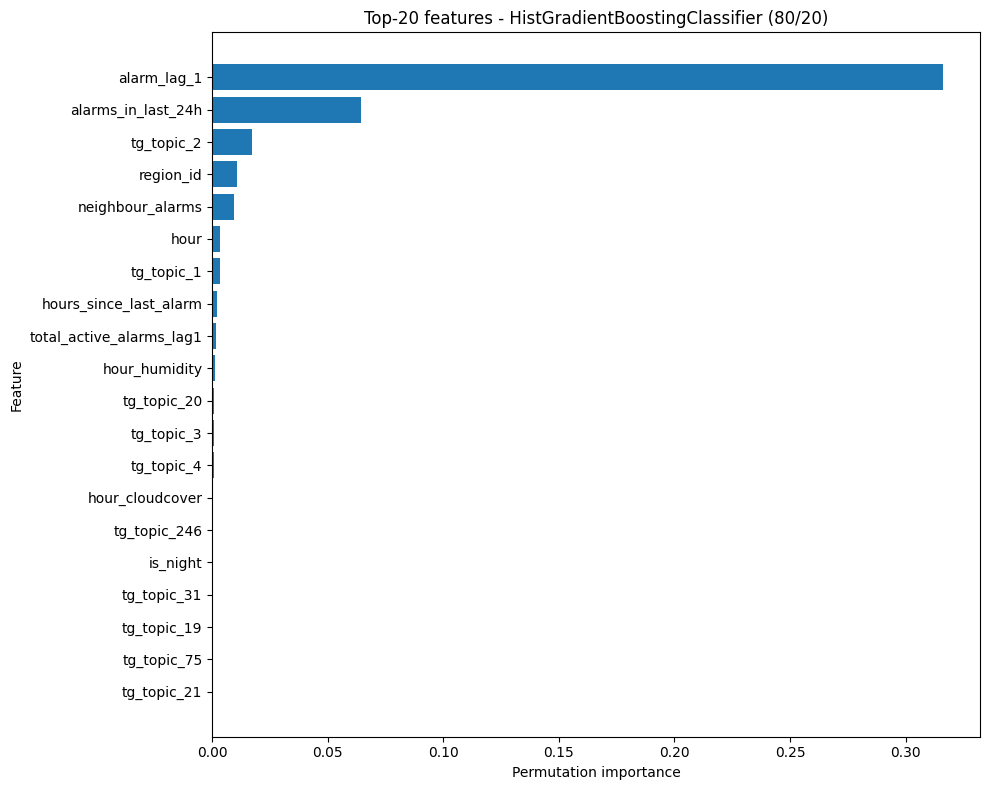

In [15]:
plt.figure(figsize=(10, 8))
plt.barh(top20["feature"][::-1], top20["importance_mean"][::-1])
plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title("Top-20 features - HistGradientBoostingClassifier (80/20)")
plt.tight_layout()
plt.show()

In [19]:
Path("../models").mkdir(exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump({
        "model": final_model,
        "threshold": best_threshold,
        "feature_names": list(X.columns),
    }, f)